# Akamai Prolexic IP Protect demo

Whenever you want DDoS protection for your non-HTTP services, Akamai has a solution called [Prolexic](https://www.akamai.com/products/prolexic-solutions). But using the classic Prolexic (PLX) *routed* or *connect* version, you must have your own AS number and be able to advertise at least a /24 (IPv4) or /48 (IPv6).  
What if you have an sFTP service you want to protect against DDoS attacks? This can't be done by App & API Protector (AAP), as that's HTTP only, so what options do we have?  

One really nice solution is Prolexic IP Protect (IPP). Just like PLX routed or connect, Prolexic IPP is a managed service, so the runbook will be followed when under attack. But unlike PLX routed/connect, IPP doesn't require your own AS number or a /24 or /48 — traffic instead flows through an Akamai Anycast Virtual IP (VIP) that you map 1:1 to your origin IP. Because both inbound and outbound traffic traverse Akamai infrastructure (inbound via the VIP, outbound to your origin via IPP Management IPs, or MIPs), the traffic flow is symmetric — unlike PLX routed, where return traffic can go directly from your origin.  

To set it up, you point a DNS record (A or CNAME, depending on your setup) at the VIP. Unlike PLX routed, which protects an entire subnet across all ports and protocols by default, IPP requires you to explicitly configure which ports/protocols each VIP protects — a single port, a port range, or up to ~100 ports per back-end IP. For sFTP, you'd configure the VIP for your sFTP port(s) specifically. Traffic hitting the VIP is routed through an Akamai scrubbing center for DDoS mitigation, then forwarded to your origin via the MIP. And just like with PLX routed/connect, you have the option to use the [Network Cloud Firewall](https://www.akamai.com/blog/security/akamai-prolexic-comes-with-network-cloud-firewall) (NCFW). 
#### The IPP layout looks like this
<div align="center">
    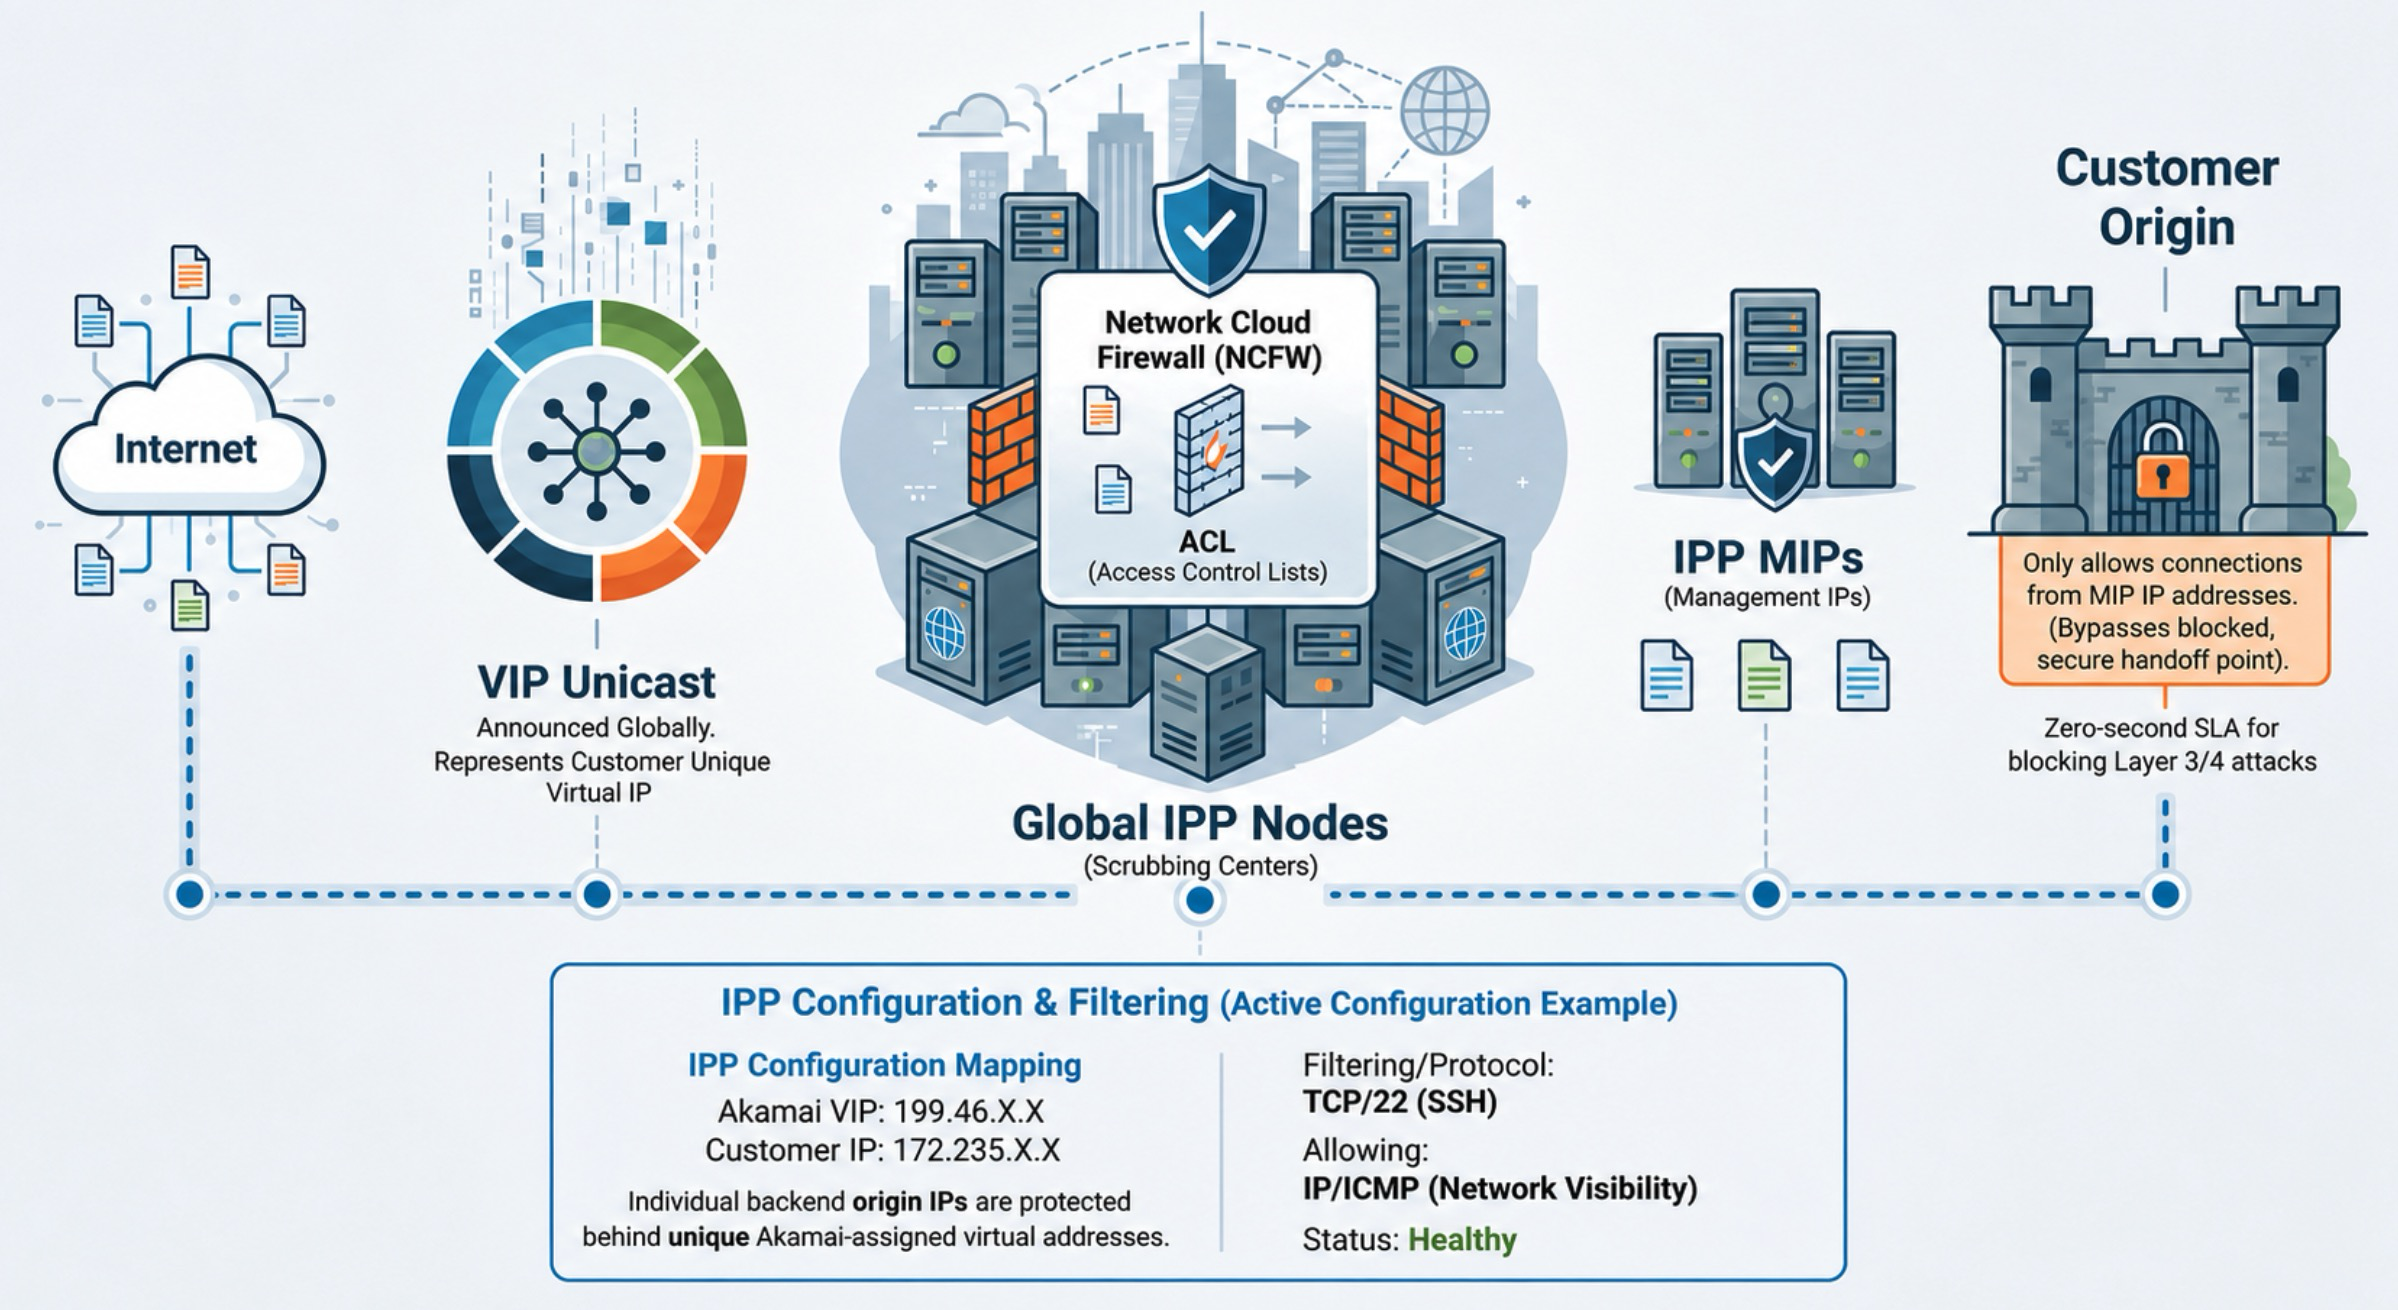
</div>  

Your assigned Anycast VIP address will be advertised across the different IPP scrubbing centers around the globe, and mitigation will take place wherever DDoS traffic is entering the PLX IPP platform.

## Set Up EdgeGrid Session

Let's first set up an EdgeGrid session using information from the `~/.edgerc` file. The correct *section* can be set via `export AKAMAI_EDGEGRID_SECTION=section`; otherwise, `default` is going to be used.

Make sure your API user has the [Prolexic IP Protect Config API permissions](https://techdocs.akamai.com/ip-protect/reference/get-started).

In [ ]:
import json
import os

import requests
from akamai.edgegrid import EdgeGridAuth, EdgeRc

edgerc_path = os.path.expanduser("~/.edgerc")

if not os.path.exists(edgerc_path):
    raise FileNotFoundError(f"Could not find .edgerc at {edgerc_path}")

section = os.getenv("AKAMAI_EDGEGRID_SECTION", "default")
account_switch_key = os.getenv("AKAMAI_ACCOUNT_SWITCH_KEY")

edgerc = EdgeRc(edgerc_path)
host = edgerc.get(section, "host")

session = requests.Session()
session.auth = EdgeGridAuth.from_edgerc(edgerc, section)
session.headers.update({
    "Accept": "application/json",
    "Content-Type": "application/json",
})

base_url = f"https://{host}"
print(f"EdgeGrid session configured for host: {host}")

if account_switch_key:
    print(f"Using AccountSwitchKey: {account_switch_key}")

## Policy domain
The first thing you need is a policy domain. A policy domain must be provisioned by Akamai beforehand. The policy domain holds your IPP configuration. By default, that will end in `_ipp` so in this example we're just looking for the first policy domain that ends with `_ipp` if the environment variable `AKAMAI_IPP_POLICY_DOMAIN` is not set.

In [ ]:
policy_domain = os.getenv("AKAMAI_IPP_POLICY_DOMAIN", "").strip()

if policy_domain:
    print(f"Using policy domain from AKAMAI_IPP_POLICY_DOMAIN: {policy_domain}")
else:
    params = {"latest": True}
    if account_switch_key:
        params["accountSwitchKey"] = account_switch_key

    response = session.get(f"{base_url}/ip-protect/v1/policy-domains", params=params)
    response.raise_for_status()

    policy_domains = response.json()
    policy_domain_names = [item.get("policyDomainName") for item in policy_domains if item.get("policyDomainName")]
    ipp_policy_domains = [name for name in policy_domain_names if "_ipp" in name]

    if not ipp_policy_domains:
        raise ValueError("No policy domain containing '_ipp' was found.")

    policy_domain = ipp_policy_domains[0]
    print(f"Selected policy domain: {policy_domain}")


## Show the MIPs

There is a list of Akamai Management IP (MIP) subnets. These MIPS will be used to connect to the origin server. You can use the list of MIP subnets in your origin to only allow the IPP platform to connect and block any other traffic.


In [ ]:
if not policy_domain:
    raise ValueError("policy_domain is empty. Run the previous cells first.")

params = {}
if account_switch_key:
    params["accountSwitchKey"] = account_switch_key

response = session.get(
    f"{base_url}/ip-protect/v1/mips",
    params=params
)

mips = response.json()
print(f"List of IPP MIP subnets: ")
print(json.dumps(mips, indent=2))

## Allocate an IPP VIP

Now let's call the [allocate](https://techdocs.akamai.com/ip-protect/reference/put-policy-domains-pdname-pd-subnets-allocate) endpoint to get a new VIP assigned. In this example, we will allocate one /32 IPv4 address. At the end of this notebook it will be *deallocated* again. This VIP is unique for a customer.

In [ ]:
if not policy_domain:
    raise ValueError("policy_domain is empty. Run the previous cells first.")

params = {}
if account_switch_key:
    params["accountSwitchKey"] = account_switch_key

payload = {
    "addVips": 1,
    "allocateIpv6": False,
}

response = session.put(
    f"{base_url}/ip-protect/v1/policy-domains/{policy_domain}/pd-subnets/allocate",
    params=params,
    json=payload,
 )
response.raise_for_status()

latest_policy_configuration = response.json()
print(f"Allocated 1 IPv4 VIP (/32) for policy domain: {policy_domain}")
print(json.dumps(latest_policy_configuration, indent=2))

## Create VIP config

Now that we have a new VIP address, assign some backend service to it. Just using our example service with the following settings:

`
customerBackend": "172.235.183.154/32",
"legacyVip": False,
"ports": "IP/ICMP,TCP/22",
"probePort": 22,
"probeType": "TCP",
"sourceIpProtocol": "NA",
"type": "PASSTHROUGH",
`


no production site. The origin IP address has an active ACL, so only IPP MIP addresses can connect to the origin service.

In [ ]:
if not policy_domain:
    raise ValueError("policy_domain is empty. Run the previous cells first.")

if not latest_policy_configuration:
    raise ValueError("latest_policy_configuration is empty. Run the previous cells first.")

existing_pd_subnets = latest_policy_configuration.get("pdSubnets") or []
if not existing_pd_subnets:
    raise ValueError(f"No pdSubnets found for policy domain: {policy_domain}")

# Use the most recently allocated /32 subnet without VIP mappings yet.
candidate_subnets = [
    subnet
    for subnet in existing_pd_subnets
    if str(subnet.get("pdSubnet", "")).endswith("/32") and not (subnet.get("vips") or [])
]

if not candidate_subnets:
    raise ValueError("No newly allocated /32 subnet without VIP mappings was found.")

target_subnet = max(candidate_subnets, key=lambda subnet: subnet.get("pdSubnetId", -1))
target_akamai_frontend = target_subnet["pdSubnet"]

new_pd_subnets = []
for subnet in existing_pd_subnets:
    subnet_payload = {
        "pdSubnet": subnet["pdSubnet"],
        "vips": [],
    }

    for vip in subnet.get("vips") or []:
        subnet_payload["vips"].append({
            "vipId": vip.get("vipId"),
            "akamaiFrontend": vip.get("akamaiFrontend"),
            "customerBackend": vip.get("customerBackend"),
            "legacyVip": vip.get("legacyVip", False),
            "ports": vip.get("ports"),
            "probePort": vip.get("probePort"),
            "probeType": vip.get("probeType"),
            "sourceIpProtocol": vip.get("sourceIpProtocol", "NA"),
            "type": vip.get("type", "PASSTHROUGH"),
        })

    if subnet["pdSubnet"] == target_subnet["pdSubnet"]:
        subnet_payload["vips"].append({
            "akamaiFrontend": target_akamai_frontend,
            "customerBackend": "172.235.183.154/32",
            "legacyVip": False,
            "ports": "IP/ICMP,TCP/22",
            "probePort": 22,
            "probeType": "TCP",
            "sourceIpProtocol": "NA",
            "type": "PASSTHROUGH",
        })

    new_pd_subnets.append(subnet_payload)

create_config_payload = {"pdSubnets": new_pd_subnets}

params = {}
if account_switch_key:
    params["accountSwitchKey"] = account_switch_key

response = session.post(
    f"{base_url}/ip-protect/v1/policy-domains/{policy_domain}/configs",
    params=params,
    json=create_config_payload,
 )
response.raise_for_status()

created_policy_configuration = response.json()
created_demo_vip = None
for subnet in created_policy_configuration.get("pdSubnets") or []:
    if subnet.get("pdSubnet") != target_akamai_frontend:
        continue

    for vip in subnet.get("vips") or []:
        matches_demo_mapping = (
            vip.get("customerBackend") == "172.235.183.154/32"
            and vip.get("ports") == "IP/ICMP,TCP/22"
            and vip.get("probePort") == 22
            and vip.get("probeType") == "TCP"
            and vip.get("sourceIpProtocol") == "NA"
            and vip.get("type") == "PASSTHROUGH"
        )
        if matches_demo_mapping and vip.get("vipId") is not None:
            created_demo_vip = {
                "vipId": vip.get("vipId"),
                "akamaiFrontend": vip.get("akamaiFrontend") or subnet.get("pdSubnet"),
                "customerBackend": vip.get("customerBackend"),
                "ports": vip.get("ports"),
                "probePort": vip.get("probePort"),
                "probeType": vip.get("probeType"),
                "sourceIpProtocol": vip.get("sourceIpProtocol"),
                "type": vip.get("type"),
            }
            break

    if created_demo_vip:
        break

if not created_demo_vip:
    raise ValueError("Could not locate the newly created demo VIP with vipId in the response.")
print(f"Created new configuration for {policy_domain} using target subnet {target_akamai_frontend}")
print(f"Tracked created demo VIP: {created_demo_vip}")
print(json.dumps(created_policy_configuration, indent=2))

## Validate in IPP UI

You should now see something like this in [Akamai Control Center](https://control.akamai.com/apps/ip-protect-config/):
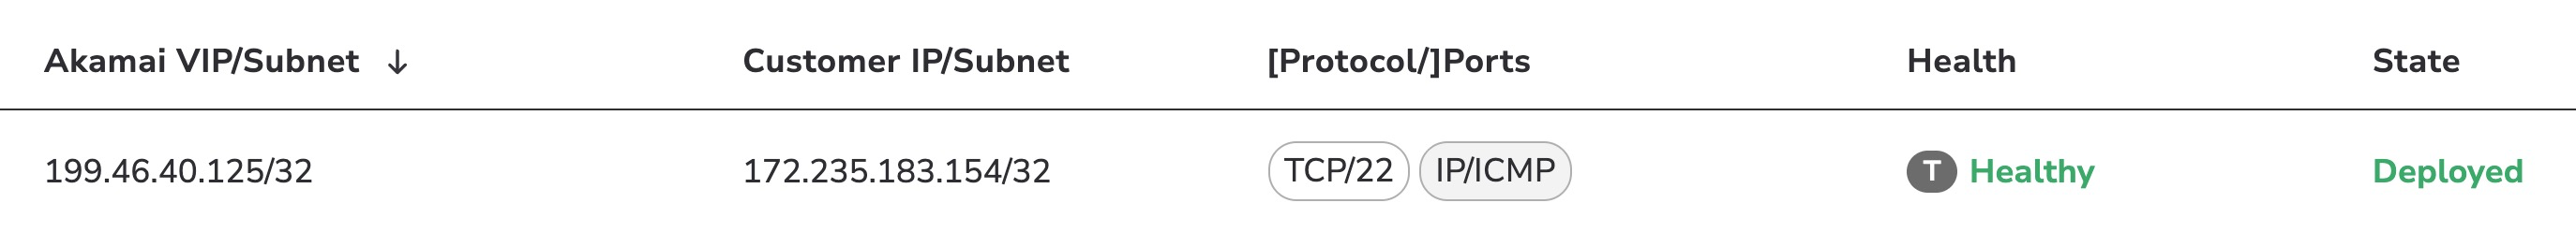

A new VIP has been assigned to our example backend service.  

*Activating an IPP configuration can take a couple of minutes*


## Clean Up

Now it's time to remove our newly created VIP mapping again.

In [ ]:
if not policy_domain:
    raise ValueError("policy_domain is empty. Run the previous cells first.")

if "created_demo_vip" not in globals() or not created_demo_vip:
    raise ValueError("created_demo_vip is missing. Run the create-mapping cell in this session first.")

if created_demo_vip.get("vipId") is None:
    raise ValueError("created_demo_vip.vipId is missing. Refusing to delete without exact VIP identity.")

params = {"latest": True}
if account_switch_key:
    params["accountSwitchKey"] = account_switch_key

response = session.get(
    f"{base_url}/ip-protect/v1/policy-domains/{policy_domain}/configs",
    params=params,
 )
response.raise_for_status()

policy_configurations = response.json()
current_configuration = policy_configurations[0] if policy_configurations else None
if not current_configuration:
    raise ValueError(f"No configurations found for policy domain: {policy_domain}")

pd_subnets = current_configuration.get("pdSubnets") or []
if not pd_subnets:
    raise ValueError(f"No pdSubnets found for policy domain: {policy_domain}")

vip_removed = False
subnet_removed = False
new_pd_subnets = []

for subnet in pd_subnets:
    vips = list(subnet.get("vips") or [])
    kept_vips = []

    for vip in vips:
        matches_demo_mapping = (
            vip.get("vipId") == created_demo_vip.get("vipId")
            and (vip.get("akamaiFrontend") or subnet.get("pdSubnet")) == created_demo_vip.get("akamaiFrontend")
            and vip.get("customerBackend") == created_demo_vip.get("customerBackend")
            and vip.get("ports") == created_demo_vip.get("ports")
            and vip.get("probePort") == created_demo_vip.get("probePort")
            and vip.get("probeType") == created_demo_vip.get("probeType")
            and vip.get("sourceIpProtocol") == created_demo_vip.get("sourceIpProtocol")
            and vip.get("type") == created_demo_vip.get("type")
        )

        if not vip_removed and matches_demo_mapping:
            vip_removed = True
            continue

        kept_vips.append(vip)

    is_removable_allocated_subnet = (
        subnet.get("pdSubnet") == created_demo_vip.get("akamaiFrontend")
        and subnet.get("legacyPdSubnet") is False
        and not kept_vips
    )
    if is_removable_allocated_subnet:
        subnet_removed = True
        continue

    subnet_payload = {
        "pdSubnet": subnet["pdSubnet"],
        "vips": [],
    }
    for vip in kept_vips:
        subnet_payload["vips"].append({
            "vipId": vip.get("vipId"),
            "akamaiFrontend": vip.get("akamaiFrontend"),
            "customerBackend": vip.get("customerBackend"),
            "legacyVip": vip.get("legacyVip", False),
            "ports": vip.get("ports"),
            "probePort": vip.get("probePort"),
            "probeType": vip.get("probeType"),
            "sourceIpProtocol": vip.get("sourceIpProtocol", "NA"),
            "type": vip.get("type", "PASSTHROUGH"),
        })

    new_pd_subnets.append(subnet_payload)

if not vip_removed:
    raise ValueError("Could not find the tracked created_demo_vip in the latest configuration.")

delete_mapping_payload = {"pdSubnets": new_pd_subnets}

params = {}
if account_switch_key:
    params["accountSwitchKey"] = account_switch_key

response = session.post(
    f"{base_url}/ip-protect/v1/policy-domains/{policy_domain}/configs",
    params=params,
    json=delete_mapping_payload,
 )
response.raise_for_status()

deleted_vip_configuration = response.json()
print(f"Removed tracked demo VIP mapping from {policy_domain}")
if subnet_removed:
    print("Also removed the now-empty allocated /32 subnet for that tracked VIP.")
print(json.dumps(deleted_vip_configuration, indent=2))